### 1. Setup and Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter
import os

In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Navigate to your dataset
dataset_path = "/content/drive/MyDrive/TopicDrugRec/dataset"
os.chdir(dataset_path)

Mounted at /content/drive


In [10]:
# Folder where we save data after processing
processed_path = './processed_data'
os.makedirs(processed_path, exist_ok=True)
# Folder where we save plots
plots_path = './plots'
os.makedirs(plots_path, exist_ok=True)

### 3. Exploratory Data Analysis (EDA)
Get basic information about the dataset:

1. Using ```ProfileReport```
```
!pip install ydata_profiling
from ydata_profiling import ProfileReport
eda = ProfileReport(df)
display(eda)
```
2. Analyzes drug ratings with considerations for:
- Skewed distribution (common in drug reviews)
- Sample size variations across drugs
- Recency of reviews
- Confidence intervals

In [11]:
df=pd.read_csv(os.path.join(dataset_path,"drug_reviews.csv"))

In [12]:
# Check duplicates
df.duplicated(subset=df.columns[1:]).sum()

np.int64(2)

In [13]:
# Identify duplicated rows (for inspection)
df[df.duplicated(subset=df.columns[1:], keep=False)]
# Remove duplicates after validation (keep first occurrence)
df_clean = df.drop_duplicates(subset=df.columns[1:], keep="first").copy()

In [14]:
df_clean['date'] = pd.to_datetime(df_clean['date'], format='mixed', errors='coerce')
print(f"✓ Parsed dates. Failed conversions: {df_clean['date'].isna().sum()}")

✓ Parsed dates. Failed conversions: 0


#####2.2.1. Build Condition Synonym Dictionaries
Common words related to **depression symptoms** often describe persistent negative feelings, physical changes, and cognitive difficulties. These words can be categorized into emotional, physical, and behavioural symptoms. The same can be done to others conditions.



In [22]:
from typing import Dict, List

# Define condition synonym groups
CONDITION_SYNONYMS = {
    'Depression': {
        'emotional': ['sadness', 'hopelessness', 'worthlessness', 'guilt',
                     'irritability', 'frustrated', 'emptiness', 'despair',
                     'depression', 'depressed', 'depressive'],
        'physical': ['fatigue', 'tiredness', 'insomnia', 'oversleeping',
                    'hypersomnia', 'pains', 'appetite changes',
                    'concentration difficulties'],
        'cognitive': ['withdrawal', 'anhedonia', 'indecisive', 'suicide',
                     'suicidal', 'slowed', 'psychomotor']
    },
    'Anxiety': {
        'emotional': ['anxious', 'anxiety', 'worry', 'fear', 'panic',
                     'nervousness', 'restlessness', 'dread', 'tension'],
        'physical': ['palpitations', 'sweating', 'trembling', 'shaking',
                    'shortness of breath', 'chest pain', 'nausea',
                    'dizziness', 'lightheaded'],
        'cognitive': ['racing thoughts', 'intrusive thoughts', 'catastrophizing']
    },
    'Birth Control': {
        'terms': ['birth control', 'contraception', 'contraceptive',
                 'pregnancy prevention', 'family planning', 'ovulation',
                 'menstrual', 'period regulation']
    },
    'Pain': {
        'types': ['pain', 'ache', 'chronic pain', 'back pain', 'neck pain',
                 'joint pain', 'arthritis', 'fibromyalgia', 'migraine',
                 'headache', 'neuropathy', 'sciatica']
    },
    'Acne': {
        'terms': ['acne', 'pimples', 'breakouts', 'blackheads', 'whiteheads',
                 'cystic acne', 'hormonal acne', 'skin problems']
    }
}

def flatten_synonyms(synonym_dict: Dict) -> List[str]:
    """Flatten nested synonym dictionary into a single list"""
    synonyms = []
    for category, terms in synonym_dict.items():
        if isinstance(terms, list):
            synonyms.extend(terms)
        elif isinstance(terms, dict):
            for subterms in terms.values():
                synonyms.extend(subterms)
    return list(set(synonyms))  # Remove duplicates

# Create flattened lists for each condition
CONDITION_TERM_MAPPING = {
    'Depression': flatten_synonyms(CONDITION_SYNONYMS['Depression']),
    'Anxiety': flatten_synonyms(CONDITION_SYNONYMS['Anxiety']),
    'Birth Control': flatten_synonyms(CONDITION_SYNONYMS['Birth Control']),
    'Pain': flatten_synonyms(CONDITION_SYNONYMS['Pain']),
    'Acne': flatten_synonyms(CONDITION_SYNONYMS['Acne'])
}

In [25]:
import re
def normalize_text(text: str) -> str:
    """Normalize text for matching"""
    if pd.isna(text):
        return ""
    return text.lower().strip()

def matches_any_term(condition_text: str, terms: List[str]) -> bool:
    """
    Check if condition text matches any term in the list
    Uses word boundaries to avoid partial matches
    """
    if not condition_text:
        return False

    condition_normalized = normalize_text(condition_text)

    for term in terms:
        term_normalized = normalize_text(term)
        # Use word boundaries to match whole words/phrases
        pattern = r'\b' + re.escape(term_normalized) + r'\b'
        if re.search(pattern, condition_normalized):
            return True

    return False

def get_standardized_condition(condition_text: str) -> str:
    """
    Map a condition to its standardized category
    Returns the matched category or None
    """
    for std_condition, terms in CONDITION_TERM_MAPPING.items():
        if matches_any_term(condition_text, terms):
            return std_condition

    return None  # No match found

def add_standardized_condition_column(df: pd.DataFrame,
                                     condition_col: str = 'condition') -> pd.DataFrame:
    """
    Add a new column with standardized conditions
    Keeps the original condition column intact
    """
    df_copy = df.copy()

    # Add standardized condition column
    df_copy['condition_std'] = df_copy[condition_col].apply(get_standardized_condition)

    # Add a flag for matched vs unmatched
    df_copy['condition_matched'] = df_copy['condition_std'].notna()

    return df_copy

In [26]:
df_clean = add_standardized_condition_column(df_clean)

In [27]:
def compute_weighted_rating(df, drug_name, condition=None, recency_weight=0.3):
    """
    Compute weighted rating that accounts for:
    1. Sample size (Bayesian average)
    2. Recency (more recent reviews weighted higher)
    3. Condition-specific ratings

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: drugName, rating, date, condition
    drug_name : str
        Name of the drug
    condition : str, optional
        Specific condition to filter by
    recency_weight : float
        Weight for recent reviews (0-1), default 0.3

    Returns:
    --------
    dict with weighted_rating, confidence, sample_size, etc.
    """
    # Ensure date column is datetime
    if not pd.api.types.is_datetime64_any_dtype(df['date']):
        df = df.copy()
        df['date'] = pd.to_datetime(df['date'])

    # Filter data
    if condition:
        drug_df = df[(df['drugName'] == drug_name) &
                     (df['condition'] == condition)].copy()
    else:
        drug_df = df[df['drugName'] == drug_name].copy()

    if len(drug_df) == 0:
        return {
            'weighted_rating': None,
            'confidence': 0.0,
            'sample_size': 0,
            'interpretation': 'No data available'
        }

    # 1. Bayesian Average (accounts for sample size)
    C = df['rating'].mean()  # Global mean rating
    m = 10  # Minimum reviews needed for confidence (tunable)

    R = drug_df['rating'].mean()  # Drug's average rating
    v = len(drug_df)  # Number of reviews

    bayesian_avg = (v * R + m * C) / (v + m)

    # 2. Recency Weight
    # More recent reviews get higher weight
    if recency_weight > 0 and len(drug_df) > 1:
        max_date = drug_df['date'].max()
        days_old = (max_date - drug_df['date']).dt.days
        max_days = days_old.max()

        if max_days > 0:
            # FIX: Calculate recency scores and normalize properly
            recency_scores = 1 - (days_old / max_days) * recency_weight
            recency_scores = recency_scores / recency_scores.sum()

            # FIX: Use .values to align arrays properly
            weighted_avg = (drug_df['rating'].values * recency_scores.values).sum()
        else:
            weighted_avg = R

        # Combine Bayesian and recency
        final_rating = 0.7 * bayesian_avg + 0.3 * weighted_avg
    else:
        final_rating = bayesian_avg

    # 3. Confidence Score
    confidence = min(1.0, v / 50)  # Caps at 50 reviews
    std_penalty = 1 - (drug_df['rating'].std() / 5) if v > 1 else 0.5
    confidence = (confidence + std_penalty) / 2

    # 4. Interpretation
    if v < 5:
        interpretation = "Very low confidence - insufficient reviews"
    elif v < 20:
        interpretation = "Low confidence - limited reviews"
    elif v < 50:
        interpretation = "Moderate confidence"
    else:
        interpretation = "High confidence - well-reviewed"

    return {
        'weighted_rating': round(final_rating, 2),
        'raw_average': round(R, 2),
        'bayesian_average': round(bayesian_avg, 2),
        'confidence': round(confidence, 2),
        'sample_size': v,
        'std_dev': round(drug_df['rating'].std(), 2) if v > 1 else 0.0,
        'interpretation': interpretation,
        'median': drug_df['rating'].median(),
        'mode': drug_df['rating'].mode()[0] if len(drug_df['rating'].mode()) > 0 else None
    }

In [28]:
# Example 1: Get weighted rating for a specific drug
print("EXAMPLE 1: Weighted Rating for Sertraline (Depression)")
print("=" * 80)
result = compute_weighted_rating(df_clean,'Sertraline','Depression')
for key, value in result.items():
    print(f"{key:20s}: {value}")

EXAMPLE 1: Weighted Rating for Sertraline (Depression)
weighted_rating     : 7.13
raw_average         : 7.14
bayesian_average    : 7.14
confidence          : 0.7
sample_size         : 663
std_dev             : 3.03
interpretation      : High confidence - well-reviewed
median              : 8.0
mode                : 10


In [29]:
drugs = ['Sertraline', 'Escitalopram', 'Fluoxetine']
results = []

for drug in drugs:
    result = compute_weighted_rating(df_clean, drug, 'Depression')
    if result['sample_size'] > 0:
        results.append({
            'Drug': drug,
            'Rating': result['weighted_rating'],
            'Confidence': result['confidence'],
            'N': result['sample_size']
        })

results_df = pd.DataFrame(results).sort_values('Rating', ascending=False)
print(results_df)

           Drug  Rating  Confidence    N
1  Escitalopram    7.54        0.72  515
2    Fluoxetine    7.25        0.70  391
0    Sertraline    7.13        0.70  663


In [30]:
# Get all drug-condition combinations
combinations = df_clean.groupby(['drugName', 'condition']).size().reset_index()

ratings = []
for _, row in combinations.iterrows():
    drug = row['drugName']
    condition = row['condition']

    result = compute_weighted_rating(df_clean, drug, condition)

    if result['sample_size'] >= 5:  # Minimum threshold
        ratings.append({
            'drug': drug,
            'condition': condition,
            'weighted_rating': result['weighted_rating'],
            'confidence': result['confidence'],
            'sample_size': result['sample_size']
        })

ratings_df = pd.DataFrame(ratings)
ratings_df.to_csv(f'{processed_path}/drug_ratings_analysis.csv', index=False)

In [ ]:
## Later: integrate with Neo4jExpert
# Calculate ratings for all drug-condition pairs
drug_conditions = df_clean.groupby(['drugName', 'condition']).size().reset_index()

with open('neo4j_drug_ratings.csv', 'w') as f:
    f.write('drug,condition,weighted_rating,confidence,sample_size\n')

    for _, row in drug_conditions.iterrows():
        result = compute_weighted_rating(
            df_clean,
            row['drugName'],
            row['condition']
        )

        if result['sample_size'] >= 5:
            f.write(f"{row['drugName']},{row['condition']},"
                   f"{result['weighted_rating']},{result['confidence']},"
                   f"{result['sample_size']}\n")

In [31]:
# Content-Based Recommendation
def get_top_drugs_for_condition(df, condition, min_confidence=0.5, top_n=5):
    """
    Get top-rated drugs for a condition using weighted ratings.
    """
    drugs = df[df['condition'] == condition]['drugName'].unique()

    rankings = []
    for drug in drugs:
        result = compute_weighted_rating(df, drug, condition)

        if result['confidence'] >= min_confidence:
            rankings.append({
                'drug': drug,
                'score': result['weighted_rating'] * result['confidence'],
                'weighted_rating': result['weighted_rating'],
                'confidence': result['confidence'],
                'sample_size': result['sample_size']
            })

    rankings_df = pd.DataFrame(rankings).sort_values('score', ascending=False)
    return rankings_df.head(top_n)

# Usage
top_drugs = get_top_drugs_for_condition(df_clean, 'Depression')
print(top_drugs)

               drug   score  weighted_rating  confidence  sample_size
46         Tramadol  8.1048             9.21        0.88           75
45       Alprazolam  7.3636             8.98        0.82           82
37            Xanax  7.3472             8.96        0.82           64
26  St. john's wort  6.7760             8.47        0.80           51
38          Parnate  6.4158             8.67        0.74           46


In [32]:
def analyze_rating_distribution_per_drug(df, min_reviews=10):
    """
    Analyze how ratings are distributed across different drugs.
    Identifies drugs with:
    - Highly polarized reviews (bimodal distribution)
    - Consistent performance (low variance)
    - Insufficient data

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: drugName, rating, date, condition
    min_reviews : int
        Minimum number of reviews to include drug in analysis

    Returns:
    --------
    DataFrame with drug-level statistics
    """
    drug_stats = []

    for drug in df['drugName'].unique():
        drug_df = df[df['drugName'] == drug]

        if len(drug_df) >= min_reviews:
            ratings = drug_df['rating'].values

            # Check for bimodality (polarized reviews)
            low_ratings = (ratings <= 4).sum()
            high_ratings = (ratings >= 8).sum()
            polarization = (low_ratings + high_ratings) / len(ratings)

            drug_stats.append({
                'drug': drug,
                'num_reviews': len(drug_df),
                'mean_rating': ratings.mean(),
                'median_rating': np.median(ratings),
                'std_rating': ratings.std(),
                'polarization_index': polarization,
                'is_polarized': polarization > 0.7,  # >70% are extreme ratings
                'cv': ratings.std() / ratings.mean(),  # Coefficient of variation
                'skewness': stats.skew(ratings),
                'kurtosis': stats.kurtosis(ratings)
            })

    return pd.DataFrame(drug_stats).sort_values('num_reviews', ascending=False)

In [33]:
# Example 2: Analyze distribution per drug
print("\n" + "=" * 80)
print("EXAMPLE 2: Drug-Level Rating Analysis")
print("=" * 80)
drug_analysis = analyze_rating_distribution_per_drug(df=df_clean,min_reviews=100)
print(drug_analysis.head(10))


EXAMPLE 2: Drug-Level Rating Analysis
                                   drug  num_reviews  mean_rating  \
4                        Levonorgestrel         4929     7.385879   
15                         Etonogestrel         4421     5.824022   
120   Ethinyl estradiol / norethindrone         3753     5.589129   
10                            Nexplanon         2892     5.643154   
47     Ethinyl estradiol / norgestimate         2790     5.802151   
7    Ethinyl estradiol / levonorgestrel         2503     5.763084   
229                         Phentermine         2085     8.776978   
21                           Sertraline         1868     7.452891   
113                        Escitalopram         1747     7.829422   
95                               Mirena         1673     6.617454   

     median_rating  std_rating  polarization_index  is_polarized        cv  \
4              9.0    3.129583            0.849462          True  0.423725   
15             6.0    3.321330            0.8

In [34]:
def condition_specific_analysis(df, condition,
                                min_reviews=10,
                                min_confidence=0.0,
                                min_rating=0.0,
                                top_n=None):
    """
    Analyze drug performance for a specific condition.
    Critical for your CB recommendation system.

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: drugName, rating, date, condition
    condition : str
        Medical condition to analyze
    min_reviews : int, default=10
        Minimum number of reviews to include drug
    min_confidence : float, default=0.0
        Minimum confidence score (0.0-1.0)
    min_rating : float, default=0.0
        Minimum weighted rating (0.0-10.0)
    top_n : int, optional
        Return only top N drugs (None = return all)

    Returns:
    --------
    DataFrame with drugs ranked by weighted rating
    """
    # Filter by condition
    condition_df = df[df['condition'] == condition]

    if len(condition_df) == 0:
        return pd.DataFrame()

    drug_rankings = []

    for drug in condition_df['drugName'].unique():
        result = compute_weighted_rating(df, drug, condition)

        # Apply all filters
        if (result['weighted_rating'] is not None and
            result['sample_size'] >= min_reviews and
            result['confidence'] >= min_confidence and
            result['weighted_rating'] >= min_rating):

            drug_rankings.append({
                'drug': drug,
                'weighted_rating': result['weighted_rating'],
                'raw_average': result['raw_average'],
                'confidence': result['confidence'],
                'sample_size': result['sample_size'],
                'std_dev': result['std_dev'],
                'interpretation': result['interpretation']
            })

    # Handle empty results
    if len(drug_rankings) == 0:
        return pd.DataFrame()

    rankings_df = pd.DataFrame(drug_rankings)

    # Calculate adjusted score (rating × confidence)
    rankings_df['adjusted_score'] = (
        rankings_df['weighted_rating'] * rankings_df['confidence']
    )

    # Sort by adjusted score
    rankings_df = rankings_df.sort_values('adjusted_score', ascending=False)
    rankings_df['rank'] = range(1, len(rankings_df) + 1)

    # Return top N if specified
    if top_n is not None:
        rankings_df = rankings_df.head(top_n)

    return rankings_df

In [35]:
# Example 3: Condition-specific rankings
print("\n" + "=" * 80)
print("EXAMPLE 3: Drug Rankings for Depression")
print("=" * 80)
depression_rankings = condition_specific_analysis(
    df_clean,
    'Depression',
    min_reviews=20,      # At least 20 reviews
    min_confidence=0.5,  # At least 50% confidence
    min_rating=7.0,      # At least 7/10 rating
    top_n=5              # Only top 5min_reviews=10)
)
print(depression_rankings.head(10))


EXAMPLE 3: Drug Rankings for Depression
               drug  weighted_rating  raw_average  confidence  sample_size  \
29         Tramadol             9.21         9.41        0.88           75   
28       Alprazolam             8.98         9.15        0.82           82   
23            Xanax             8.96         9.17        0.82           64   
17  St. john's wort             8.47         8.67        0.80           51   
24          Parnate             8.67         8.91        0.74           46   

    std_dev                   interpretation  adjusted_score  rank  
29     1.15  High confidence - well-reviewed          8.1048     1  
28     1.78  High confidence - well-reviewed          7.3636     2  
23     1.80  High confidence - well-reviewed          7.3472     3  
17     1.96  High confidence - well-reviewed          6.7760     4  
24     2.25              Moderate confidence          6.4158     5  


In [36]:
# Get rankings for all conditions
all_rankings = []

for condition in df_clean['condition'].unique():
    rankings = condition_specific_analysis(
        df_clean,
        condition,
        min_reviews=10,
        min_confidence=0.5,  # W/o confidence
        min_rating=0,      # W/o rating
        top_n=5              # All)
    )
    if len(rankings) > 0:
        rankings['condition'] = condition
        all_rankings.append(rankings)

if all_rankings:
    final_df = pd.concat(all_rankings, ignore_index=True)
    # Uncomment to save:
    final_df.to_csv(f'{processed_path}/drug_rankings_by_condition_top5.csv', index=False)
    print(f"Total condition-drug pairs with ≥10 reviews: {len(final_df)}")
    print(f"\nSample data:")
    print(final_df.head(10)[['condition', 'drug', 'weighted_rating',
                              'confidence', 'sample_size']].to_string(index=False))

Total condition-drug pairs with ≥10 reviews: 655

Sample data:
    condition              drug  weighted_rating  confidence  sample_size
         ADHD Dextroamphetamine             8.59        0.79           94
         ADHD       Adderall XR             8.19        0.80          139
         ADHD         Dexedrine             8.26        0.77           57
         ADHD          Adderall             8.18        0.77          227
         ADHD          Daytrana             8.14        0.75           61
Birth Control           Kyleena             7.59        0.75          205
Birth Control        Ortho Evra             7.40        0.71          291
Birth Control             Skyla             7.24        0.71         1074
Birth Control       Generess Fe             6.96        0.70          128
Birth Control    Levonorgestrel             7.04        0.69         2884


In [39]:
def detect_anomalous_ratings(df, z_threshold=2.5, min_reviews=10):
    """
    Detect drugs with unusual rating patterns.
    May indicate:
    - Gaming/fake reviews
    - Exceptional drugs (very good or very bad)
    - Data quality issues

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: drugName, rating, date, condition
    z_threshold : float
        Number of standard deviations for outlier detection

    Returns:
    --------
    DataFrame of drugs with anomalous ratings
    """
    drug_means = df.groupby('drugName')['rating'].agg(['mean', 'count', 'std'])
    drug_means = drug_means[drug_means['count'] >= min_reviews]  # Min 10 reviews

    # Z-score based on mean rating
    overall_mean = df['rating'].mean()
    overall_std = df['rating'].std()

    drug_means['z_score'] = (drug_means['mean'] - overall_mean) / overall_std

    anomalies = drug_means[abs(drug_means['z_score']) > z_threshold]

    return anomalies.sort_values('z_score', ascending=False)


In [40]:
# Example 4: Detect anomalies
print("\n" + "=" * 80)
print("EXAMPLE 4: Anomalous Rating Patterns")
print("=" * 80)
anomalies = detect_anomalous_ratings(df=df_clean)
print(anomalies.head())


EXAMPLE 4: Anomalous Rating Patterns
Empty DataFrame
Columns: [mean, count, std, z_score]
Index: []


In [37]:
def detect_anomalous_drugs(df, method='auto', min_reviews=10):
    """
    Statistically sound outlier detection for drug ratings.

    Parameters:
    -----------
    method : str
        'auto' - Choose based on normality test (RECOMMENDED)
        'zscore' - Z-score method (assumes normality)
        'iqr' - IQR method (non-parametric)
        'mad' - MAD method (most robust)

    Returns:
    --------
    DataFrame of anomalous drugs with statistical metrics
    """
    from scipy.stats import normaltest

    # Calculate drug statistics
    drug_stats = df.groupby('drugName').agg({
        'rating': ['mean', 'count', 'std', 'median']
    })
    drug_stats.columns = ['mean_rating', 'review_count', 'std_rating', 'median_rating']
    drug_stats = drug_stats[drug_stats['review_count'] >= min_reviews]

    # Test normality
    _, p_value = normaltest(drug_stats['mean_rating'])
    is_normal = p_value > 0.05

    # Auto-select method
    if method == 'auto':
        method = 'zscore' if is_normal else 'iqr'
        print(f"Auto-selected: {method} (normality p={p_value:.4f})")

    # Detect outliers
    if method == 'zscore':
        threshold = 2.58  # 99% CI
        mean = drug_stats['mean_rating'].mean()
        std = drug_stats['mean_rating'].std()
        drug_stats['z_score'] = (drug_stats['mean_rating'] - mean) / std
        outliers = drug_stats[abs(drug_stats['z_score']) > threshold]

    elif method == 'iqr':
        Q1 = drug_stats['mean_rating'].quantile(0.25)
        Q3 = drug_stats['mean_rating'].quantile(0.75)
        IQR = Q3 - Q1
        outliers = drug_stats[
            (drug_stats['mean_rating'] < Q1 - 1.5*IQR) |
            (drug_stats['mean_rating'] > Q3 + 1.5*IQR)
        ]

    elif method == 'mad':
        median = drug_stats['mean_rating'].median()
        mad = np.median(np.abs(drug_stats['mean_rating'] - median))
        drug_stats['modified_z'] = 0.6745 * (drug_stats['mean_rating'] - median) / mad
        outliers = drug_stats[abs(drug_stats['modified_z']) > 3.5]

    return outliers.sort_values('mean_rating')

In [38]:
outliers = detect_anomalous_drugs(df=df_clean, method='auto')
print(outliers.head())

Auto-selected: iqr (normality p=0.0000)
                                          mean_rating  review_count  \
drugName                                                              
ProAir RespiClick                            1.157895            38   
Monistat 1-Day or Night Combination Pack     2.000000            15   
Systane                                      2.090909            11   
Alendronate                                  2.689655            29   
Larin Fe 1 / 20                              2.800000            10   

                                          std_rating  median_rating  
drugName                                                             
ProAir RespiClick                           0.436591            1.0  
Monistat 1-Day or Night Combination Pack    2.299068            1.0  
Systane                                     2.773249            1.0  
Alendronate                                 2.867346            1.0  
Larin Fe 1 / 20                           

In [ ]:
def detect_outliers_iqr(df, min_reviews=10):
    """
    IQR outlier detection (non-parametric, robust).

    Doesn't assume normality.
    Based on quartiles, resistant to extreme values.
    """
    drug_stats = df.groupby('drugName')['rating'].agg(['mean', 'count'])
    drug_stats = drug_stats[drug_stats['count'] >= min_reviews]

    Q1 = drug_stats['mean'].quantile(0.25)
    Q3 = drug_stats['mean'].quantile(0.75)
    IQR = Q3 - Q1

    # Tukey's fences
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = drug_stats[
        (drug_stats['mean'] < lower_bound) |
        (drug_stats['mean'] > upper_bound)
    ]

    return outliers

In [39]:
def visualize_comprehensive_distribution(df, output_path='/mnt/user-data/outputs'):
    """
    Create comprehensive visualization of rating patterns.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Overall distribution
    ax1 = axes[0, 0]
    rating_counts = df['rating'].value_counts().sort_index()
    ax1.bar(rating_counts.index, rating_counts.values,
            color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(rating_counts))))
    ax1.set_xlabel('Rating')
    ax1.set_ylabel('Count')
    ax1.set_title('Overall Rating Distribution')
    ax1.grid(axis='y', alpha=0.3)

    # 2. Distribution by sample size
    ax2 = axes[0, 1]
    drug_review_counts = df.groupby('drugName').size()
    ax2.hist(drug_review_counts, bins=50, edgecolor='black', alpha=0.7)
    ax2.set_xlabel('Number of Reviews per Drug')
    ax2.set_ylabel('Number of Drugs')
    ax2.set_title('Review Count Distribution Across Drugs')
    ax2.axvline(drug_review_counts.median(), color='red',
                linestyle='--', label=f'Median: {drug_review_counts.median():.0f}')
    ax2.legend()

    # 3. Rating vs Review Count
    ax3 = axes[1, 0]
    drug_stats = df.groupby('drugName').agg({
        'rating': ['mean', 'count']
    }).reset_index()
    drug_stats.columns = ['drug', 'mean_rating', 'count']

    scatter = ax3.scatter(drug_stats['count'], drug_stats['mean_rating'],
                            alpha=0.5, c=drug_stats['count'],
                            cmap='viridis', s=30)
    ax3.set_xlabel('Number of Reviews')
    ax3.set_ylabel('Mean Rating')
    ax3.set_title('Rating vs. Review Count')
    ax3.set_xscale('log')
    plt.colorbar(scatter, ax=ax3, label='Review Count')

    # 4. Temporal trends
    ax4 = axes[1, 1]
    monthly_avg = df.set_index('date').resample('M')['rating'].mean()
    ax4.plot(monthly_avg.index, monthly_avg.values, linewidth=2)
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Average Rating')
    ax4.set_title('Average Rating Over Time')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{output_path}/comprehensive_rating_analysis.png',
                dpi=300, bbox_inches='tight')
    print(f"✓ Saved comprehensive analysis to {output_path}")
    plt.show()


EXAMPLE 5: Creating Comprehensive Visualization


/tmp/ipython-input-1265269552.py:46: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df.set_index('date').resample('M')['rating'].mean()


✓ Saved comprehensive analysis to ./plots


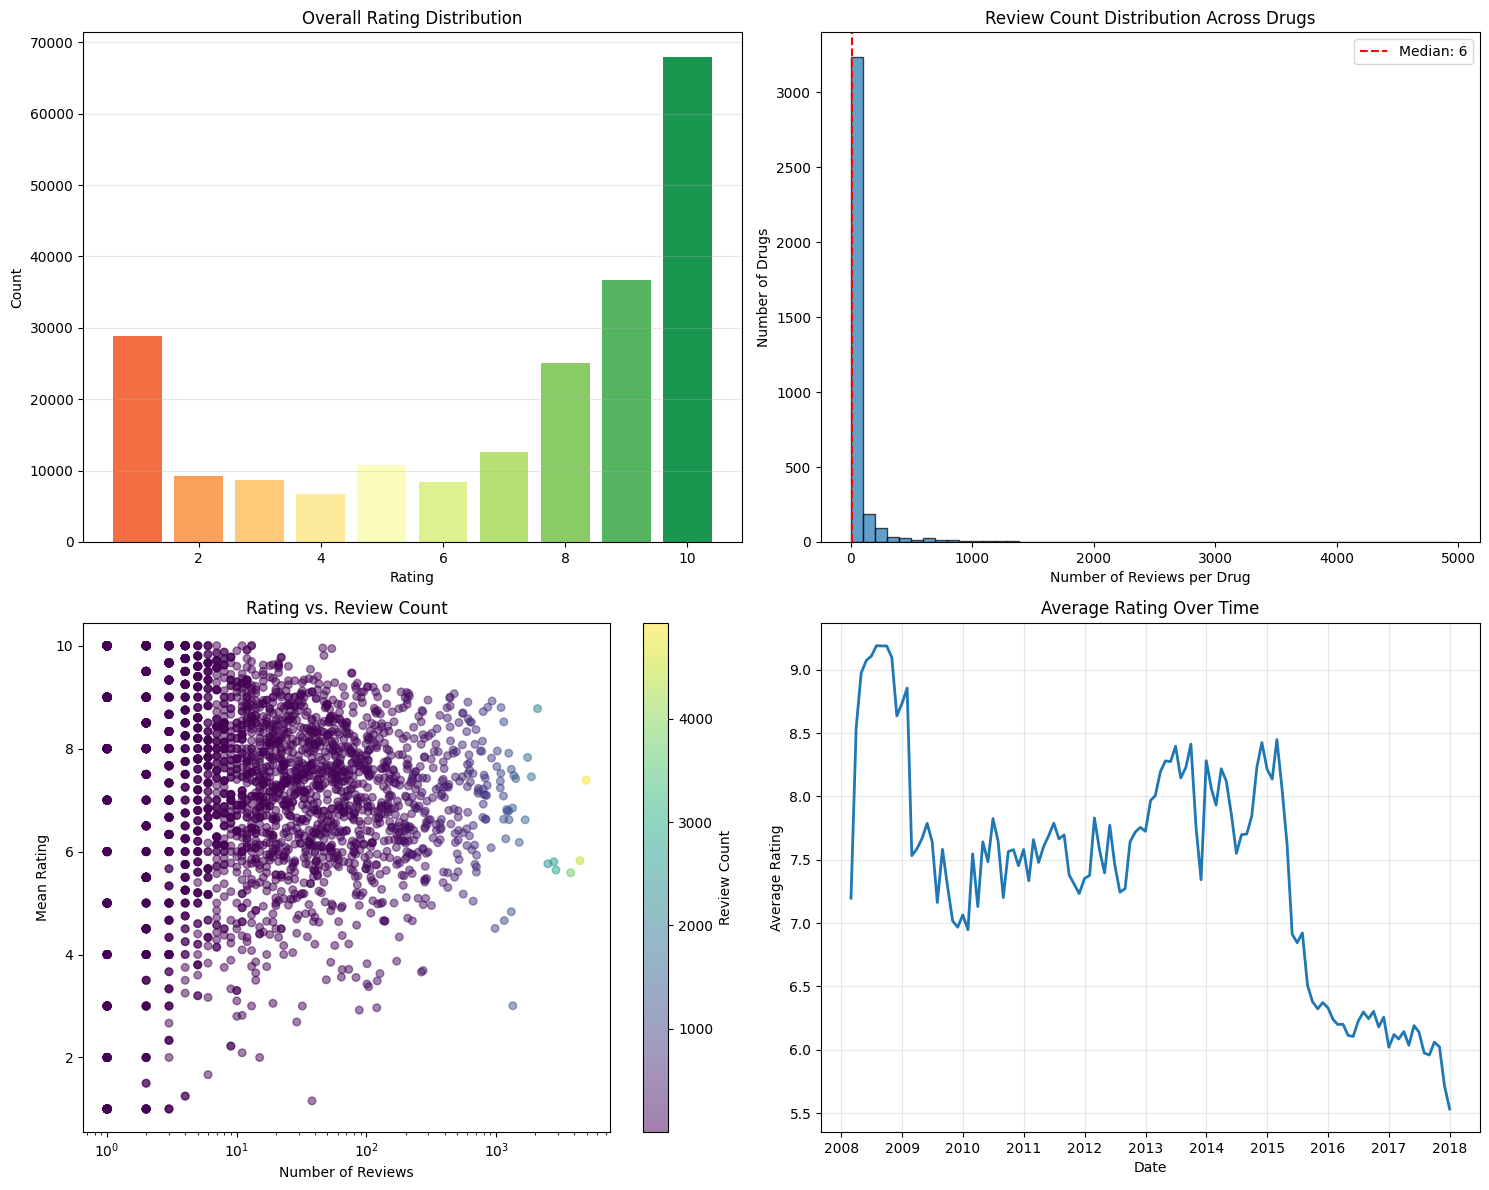

In [40]:
# Example 5: Visualization
print("\n" + "=" * 80)
print("EXAMPLE 5: Creating Comprehensive Visualization")
print("=" * 80)
visualize_comprehensive_distribution(df_clean, output_path=plots_path)

#### Weighted Rating Calculator for Drug Recommendation System
Addresses RQ1 (accuracy + safety)

1. Calculates confidence-weighted ratings for each drug
2. Replaces raw ratings with weighted ratings in your dataset
3. Prepares data for your CB recommendation component (Section 1.3)
4. Integrates with your Neo4j KG framework

**Confidence score**: "How much do I trust this drug's rating?"

1. Sample Size Confidence (weight_sample_size)

What it measures: *How many reviews exist*

Why it matters:

- 10 reviews saying "rating 9" is less reliable than 1,000 reviews saying "rating 9"
- Law of large numbers: more data → more stable estimates

```
sample_confidence = log10(review_count) / log10(max_review_count)
```

**Example:**
```
Drug A: 10 reviews   → sample_confidence = 0.33
Drug B: 100 reviews  → sample_confidence = 0.67  
Drug C: 1000 reviews → sample_confidence = 1.00
```

2. Consistency Confidence (weight_consistency)

What it measures: *How much reviews agree with each other*

Why it matters:

- If all reviews say 8-9, the mean is trustworthy
- If reviews are split 1-2-3-8-9-10, the mean is misleading

```
consistency_confidence = 1 - (std_dev / max_std_dev)
```

**Example:**
```
Drug A: Ratings = [8, 8, 9, 9, 8]    → std = 0.5  → consistency = 0.95 (high agreement)
Drug B: Ratings = [1, 5, 9, 3, 10]   → std = 3.7  → consistency = 0.10 (low agreement)
```
When to Use Different Weights:

1. Scenario 1: Conservative Approach
```
weight_sample_size = 0.3
weight_consistency = 0.7
```
- Safety is critical (you're in healthcare!)
- You'd rather recommend drugs where patients consistently agree
- You don't want to recommend "polarizing" drugs

**Good for:** Objective of 95% safety compliance

2. Scenario 2: Popularity-Based (Prioritize Volume)
```
weight_sample_size = 0.8
weight_consistency = 0.2
```
- You trust the "wisdom of crowds"
- Popular drugs are inherently more reliable
- You want to recommend widely-used medications

**Good for:** Exploratory recommendations, low-risk conditions

3. Scenario 3: Balanced (Default)
```
weight_sample_size = 0.6
weight_consistency = 0.4
```
- You want both factors to matter
- Moderate approach for most use cases

**Good for:** General-purpose recommendations

#### Evaluation Metrics

1. Precision@k (Target: 0.55-0.60):

- Conservative weights (0.3, 0.7) → Higher precision, fewer recommendations
- Popularity weights (0.8, 0.2) → More recommendations, might lower precision

2. NDCG@10 (Target: 0.55-0.65):

- Use weighted_rating for relevance scores
- The weights affect which drugs appear in Top@10

3. Safety Compliance (Target: 95%):

- Conservative weights help achieve this
- Polarizing drugs get filtered out more aggressively

In [52]:
def calculate_confidence_score(df,
                               min_reviews=10,
                               weight_sample_size=0.6,
                               weight_consistency=0.4,
                               condition_specific=True):
    """
    Calculate confidence-weighted drug scores.

    Parameters:
    -----------
    df : pandas.DataFrame
        Your cleaned drug review dataset
    min_reviews : int
        Minimum number of reviews to calculate confidence (default: 10)
    weight_sample_size : float
        Weight for sample size component (0-1, default: 0.6)
        Higher = prioritize drugs with many reviews
        Lower = accept drugs with fewer reviews if consistent
    weight_consistency : float
        Weight for consistency component (0-1, default: 0.4)
        Higher = prioritize drugs where reviews strongly agree
        Lower = accept drugs with mixed reviews if popular
        Note: weight_sample_size + weight_consistency should equal 1.0
    condition_specific : bool
        If True, calculate ratings per drug-condition pair (recommended for CB system)
        If False, calculate global ratings per drug

    Returns:
    --------
    pandas.DataFrame
        Drug statistics with weighted ratings and confidence scores

    Weight Guidelines:
    ------------------
    Conservative (0.3 sample, 0.7 consistency): Prioritize agreement, safety-critical
    Balanced (0.6 sample, 0.4 consistency): General purpose [DEFAULT]
    Popularity (0.8 sample, 0.2 consistency): Prioritize volume, exploratory
    """

    # Validate weights
    if not (0 <= weight_sample_size <= 1 and 0 <= weight_consistency <= 1):
        raise ValueError("Weights must be between 0 and 1")

    if abs((weight_sample_size + weight_consistency) - 1.0) > 0.01:
        print(f"WARNING: Weights sum to {weight_sample_size + weight_consistency:.2f}, not 1.0")
        print("Normalizing weights...")
        total = weight_sample_size + weight_consistency
        weight_sample_size = weight_sample_size / total
        weight_consistency = weight_consistency / total
        print(f"Adjusted: sample={weight_sample_size:.2f}, consistency={weight_consistency:.2f}")

    # Group by drug-condition pair (aligns with your CB approach)
    if condition_specific:
        group_cols = ['drugName', 'condition_std']
        print("Calculating condition-specific weighted ratings...")
    else:
        group_cols = ['drugName']
        print("Calculating global weighted ratings...")

    # Calculate basic statistics
    drug_stats = df.groupby(group_cols).agg({
        'rating': ['mean', 'count', 'std', 'median', 'min', 'max']
    })

    drug_stats.columns = ['mean', 'count', 'std', 'median', 'min', 'max']

    # Filter by minimum review count
    original_count = len(drug_stats)
    drug_stats = drug_stats[drug_stats['count'] >= min_reviews]
    filtered_count = original_count - len(drug_stats)

    print(f"Filtered {filtered_count} drug-condition pairs with < {min_reviews} reviews")
    print(f"Remaining: {len(drug_stats)} drug-condition pairs")

    # === CONFIDENCE COMPONENT 1: Sample Size ===
    # More reviews = higher confidence (log scale to handle large differences)
    drug_stats['sample_confidence'] = np.log10(drug_stats['count']) / np.log10(drug_stats['count'].max())

    # === CONFIDENCE COMPONENT 2: Consistency (inverse of variance) ===
    # Low variance = more consistent reviews = higher confidence
    max_std = drug_stats['std'].quantile(0.95)  # Cap at 95th percentile to avoid outlier influence
    drug_stats['consistency_confidence'] = 1 - (drug_stats['std'] / max_std)
    drug_stats['consistency_confidence'] = drug_stats['consistency_confidence'].clip(0, 1)

    # === BIMODALITY DETECTION ===
    # Large gap between mean and median indicates polarizing drug
    # (some patients love it, others hate it)
    drug_stats['mean_median_diff'] = abs(drug_stats['mean'] - drug_stats['median'])
    drug_stats['is_polarizing'] = drug_stats['mean_median_diff'] > 1.5

    # === OVERALL CONFIDENCE SCORE (0-1) ===
    # Weighted combination of sample size and consistency
    # User-configurable to balance between volume and agreement
    drug_stats['confidence_score'] = (
        weight_sample_size * drug_stats['sample_confidence'] +
        weight_consistency * drug_stats['consistency_confidence']
    )

    print(f"\nConfidence score weights:")
    print(f"  Sample size: {weight_sample_size:.2f} (prioritize volume)")
    print(f"  Consistency: {weight_consistency:.2f} (prioritize agreement)")

    # Penalize polarizing drugs (reduce confidence by 20%)
    drug_stats.loc[drug_stats['is_polarizing'], 'confidence_score'] *= 0.8

    # === WEIGHTED RATING (THIS REPLACES RAW RATING) ===
    # Scale the mean rating by confidence score
    # Low confidence → rating pulled toward neutral (5.5 on 10-point scale)
    # High confidence → rating stays close to mean
    neutral_rating = 5.5
    drug_stats['weighted_rating'] = (
        drug_stats['mean'] * drug_stats['confidence_score'] +
        neutral_rating * (1 - drug_stats['confidence_score'])
    )

    # Round to 2 decimal places for readability
    drug_stats['weighted_rating'] = drug_stats['weighted_rating'].round(2)
    drug_stats['confidence_score'] = drug_stats['confidence_score'].round(3)

    return drug_stats

In [63]:
def merge_weighted_ratings_to_dataset(df, drug_stats, condition_specific=True):
    """
    Merge weighted ratings back into your original dataset.

    This creates a new column 'rating_weighted' while preserving original 'rating'.
    """

    if condition_specific:
        merge_cols = ['drugName', 'condition_std']
    else:
        merge_cols = ['drugName']

    # Reset index to make merge columns accessible
    drug_stats_merge = drug_stats.reset_index()[
        merge_cols + ['weighted_rating', 'confidence_score', 'is_polarizing']
    ].copy()

    # Ensure correct dtypes before merging
    drug_stats_merge['weighted_rating'] = drug_stats_merge['weighted_rating'].astype('float64')
    drug_stats_merge['confidence_score'] = drug_stats_merge['confidence_score'].astype('float64')
    drug_stats_merge['is_polarizing'] = drug_stats_merge['is_polarizing'].astype('bool')

    # Merge with original dataset
    df_merged = df.merge(
        drug_stats_merge,
        on=merge_cols,
        how='left'
    )

    # For numeric columns, fillna works fine (no downcasting warning for floats)
    df_merged['rating_weighted'] = df_merged['weighted_rating'].fillna(df_merged['rating'])
    df_merged['confidence_score'] = df_merged['confidence_score'].fillna(0.0)

    # For boolean columns, use numpy.where to avoid fillna downcasting warning
    import numpy as np
    df_merged['is_polarizing'] = np.where(
        df_merged['is_polarizing'].isna(),
        False,
        df_merged['is_polarizing']
    ).astype('bool')

    # Drop temporary column
    df_merged = df_merged.drop('weighted_rating', axis=1)

    return df_merged

In [54]:
def analyze_rating_changes(df_merged):
    """
    Analyze how weighted ratings differ from raw ratings.
    Useful for validating your approach.
    """

    # Calculate difference between raw and weighted
    df_merged['rating_diff'] = df_merged['rating_weighted'] - df_merged['rating']

    print("\n" + "=" * 80)
    print("RATING CHANGE ANALYSIS")
    print("=" * 80)

    print(f"\nAverage raw rating: {df_merged['rating'].mean():.2f}")
    print(f"Average weighted rating: {df_merged['rating_weighted'].mean():.2f}")
    print(f"Average confidence score: {df_merged['confidence_score'].mean():.3f}")

    print(f"\nRecords with polarizing drugs: {df_merged['is_polarizing'].sum()} ({df_merged['is_polarizing'].sum() / len(df_merged) * 100:.1f}%)")

    print(f"\nRating changes:")
    print(f"  Mean absolute change: {abs(df_merged['rating_diff']).mean():.2f}")
    print(f"  Max increase: {df_merged['rating_diff'].max():.2f}")
    print(f"  Max decrease: {df_merged['rating_diff'].min():.2f}")

    # Show examples of biggest changes
    print("\nBiggest rating INCREASES (low confidence → boosted):")
    top_increases = df_merged.nlargest(5, 'rating_diff')[
        ['drugName', 'condition_std', 'rating', 'rating_weighted', 'confidence_score']
    ]
    print(top_increases.to_string(index=False))

    print("\nBiggest rating DECREASES (low confidence → penalized):")
    top_decreases = df_merged.nsmallest(5, 'rating_diff')[
        ['drugName', 'condition_std', 'rating', 'rating_weighted', 'confidence_score']
    ]
    print(top_decreases.to_string(index=False))

In [68]:
def export_for_neo4j(drug_stats, output_dir='/mnt/user-data/outputs'):
    """
    Export weighted ratings in Neo4j-ready CSV format.
    Supports your KG framework objective (Section 1.3, point 3).
    """

    # Prepare Neo4j import file
    neo4j_export = drug_stats.reset_index()

    # Create unique ID for each drug-condition pair
    if 'condition_std' in neo4j_export.columns:
        neo4j_export['pair_id'] = (
            neo4j_export['drugName'].str.replace(' ', '_') +
            '__' +
            neo4j_export['condition_std'].str.replace(' ', '_')
        )
    else:
        neo4j_export['pair_id'] = neo4j_export['drugName'].str.replace(' ', '_')

    # Select columns for Neo4j
    neo4j_export = neo4j_export[[
        'pair_id', 'drugName', 'condition_std',
        'mean', 'count', 'std', 'weighted_rating', 'confidence_score', 'is_polarizing'
    ]].rename(columns={
        'pair_id': 'id:ID',
        'drugName': 'drug_name',
        'condition_std': 'condition_name',
        'mean': 'raw_rating_mean',
        'count': 'review_count:int',
        'std': 'rating_std',
        'weighted_rating': 'weighted_rating:float',
        'confidence_score': 'confidence_score:float',
        'is_polarizing': 'is_polarizing:boolean'
    })

    # Add label column
    neo4j_export[':LABEL'] = 'DrugConditionRating'

    # Save
    output_path = f'{output_dir}/neo4j_drug_condition_ratings.csv'
    neo4j_export.to_csv(output_path, index=False)

    print(f"\n[SUCCESS] Neo4j import file saved: {output_path}")

    # Generate Cypher import query
    cypher_query = """
// Import drug-condition ratings into Neo4j

// 1. Load the CSV
LOAD CSV WITH HEADERS FROM 'file:///neo4j_drug_condition_ratings.csv' AS row

// 2. Create or merge drug node
MERGE (d:Drug {name: row.drug_name})

// 3. Create or merge condition node
MERGE (c:Condition {name: row.condition_name})

// 4. Create rating relationship
CREATE (d)-[r:HAS_RATING_FOR]->(c)
SET r.raw_rating_mean = toFloat(row.raw_rating_mean),
    r.review_count = toInteger(row.review_count),
    r.rating_std = toFloat(row.rating_std),
    r.weighted_rating = toFloat(row.weighted_rating),
    r.confidence_score = toFloat(row.confidence_score),
    r.is_polarizing = toBoolean(row.is_polarizing)

RETURN count(*) AS relationships_created;
"""

    cypher_path = f'{output_dir}/neo4j_import_ratings.cypher'
    with open(cypher_path, 'w') as f:
        f.write(cypher_query)

    print(f"[SUCCESS] Cypher query saved: {cypher_path}")

    return neo4j_export

In [74]:
def visualize_confidence_distribution(drug_stats, output_dir='/mnt/user-data/outputs'):
    """
    Create visualizations to understand confidence scores.
    """

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Confidence score distribution
    axes[0, 0].hist(drug_stats['confidence_score'], bins=30, color='skyblue', edgecolor='black')
    axes[0, 0].set_xlabel('Confidence Score', fontsize=11, weight='bold')
    axes[0, 0].set_ylabel('Frequency', fontsize=11, weight='bold')
    axes[0, 0].set_title('Distribution of Confidence Scores', fontsize=13, weight='bold')
    axes[0, 0].axvline(drug_stats['confidence_score'].mean(), color='red', linestyle='--',
                       label=f'Mean: {drug_stats["confidence_score"].mean():.3f}')
    axes[0, 0].legend()

    # 2. Sample size vs confidence
    axes[0, 1].scatter(drug_stats['count'], drug_stats['confidence_score'],
                       alpha=0.5, s=20, color='green')
    axes[0, 1].set_xlabel('Number of Reviews', fontsize=11, weight='bold')
    axes[0, 1].set_ylabel('Confidence Score', fontsize=11, weight='bold')
    axes[0, 1].set_title('Sample Size vs Confidence', fontsize=13, weight='bold')
    axes[0, 1].set_xscale('log')

    # 3. Raw rating vs weighted rating
    axes[1, 0].scatter(drug_stats['mean'], drug_stats['weighted_rating'],
                       alpha=0.5, s=20, color='purple')
    axes[1, 0].plot([0, 10], [0, 10], 'r--', label='y=x (no change)')
    axes[1, 0].set_xlabel('Raw Mean Rating', fontsize=11, weight='bold')
    axes[1, 0].set_ylabel('Weighted Rating', fontsize=11, weight='bold')
    axes[1, 0].set_title('Raw vs Weighted Ratings', fontsize=13, weight='bold')
    axes[1, 0].legend()
    axes[1, 0].set_xlim(0, 10)
    axes[1, 0].set_ylim(0, 10)

    # 4. Polarizing drugs
    polarizing_count = drug_stats['is_polarizing'].sum()
    not_polarizing_count = len(drug_stats) - polarizing_count

    axes[1, 1].bar(['Not Polarizing', 'Polarizing'],
                   [not_polarizing_count, polarizing_count],
                   color=['lightgreen', 'salmon'], edgecolor='black')
    axes[1, 1].set_ylabel('Count', fontsize=11, weight='bold')
    axes[1, 1].set_title('Polarizing vs Non-Polarizing Drugs', fontsize=13, weight='bold')

    for i, v in enumerate([not_polarizing_count, polarizing_count]):
        axes[1, 1].text(i, v, f'{v}\n({v/len(drug_stats)*100:.1f}%)',
                        ha='center', va='bottom', fontsize=10, weight='bold')

    plt.tight_layout()

    plt.savefig(f'{output_dir}/confidence_analysis.png', dpi=300, bbox_inches='tight')
    print(f"[SUCCESS] Visualization saved: {output_dir}")
    plt.close()

In [58]:
# Step 1: Calculate weighted ratings
drug_stats = calculate_confidence_score(
    df=df_clean,
    min_reviews=10,
    weight_sample_size=0.6,
    weight_consistency=0.4,
    condition_specific=True
)

Calculating condition-specific weighted ratings...
Filtered 575 drug-condition pairs with < 10 reviews
Remaining: 599 drug-condition pairs

Confidence score weights:
  Sample size: 0.60 (prioritize volume)
  Consistency: 0.40 (prioritize agreement)


In [78]:
summary_stats = drug_stats.describe()[
        ['mean', 'count', 'std', 'weighted_rating', 'confidence_score']
    ].round(2)
print(summary_stats)

         mean    count     std  weighted_rating  confidence_score
count  599.00   599.00  599.00           599.00            599.00
mean     7.23   171.77    2.84             6.23              0.38
std      1.35   378.60    0.73             0.64              0.12
min      2.98    10.00    0.29             4.64              0.13
25%      6.32    21.00    2.50             5.77              0.29
50%      7.36    60.00    3.02             6.12              0.38
75%      8.28   172.50    3.33             6.64              0.47
max      9.92  4534.00    4.22             8.01              0.67


In [64]:
# Step 2: Merge back to dataset
df_merged = merge_weighted_ratings_to_dataset(
    df_clean,
    drug_stats,
    condition_specific=True)

In [65]:
df_merged.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount,condition_std,condition_matched,confidence_score,is_polarizing,rating_weighted
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,None,False,0.000,False,9.00
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,None,False,0.000,False,8.00
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17,Birth Control,True,0.187,True,5.88
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10,Birth Control,True,0.397,True,6.26
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37,None,False,0.000,False,9.00


In [79]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215061 entries, 0 to 215060
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   uniqueID           215061 non-null  int64         
 1   drugName           215061 non-null  object        
 2   condition          213867 non-null  object        
 3   review             215061 non-null  object        
 4   rating             215061 non-null  int64         
 5   date               215061 non-null  datetime64[ns]
 6   usefulCount        215061 non-null  int64         
 7   condition_std      104670 non-null  object        
 8   condition_matched  215061 non-null  bool          
 9   confidence_score   215061 non-null  float64       
 10  is_polarizing      215061 non-null  bool          
 11  rating_weighted    215061 non-null  float64       
 12  rating_diff        215061 non-null  float64       
dtypes: bool(2), datetime64[ns](1), float64(3), i

In [66]:
# Step 3: Analyze changes
analyze_rating_changes(df_merged)


RATING CHANGE ANALYSIS

Average raw rating: 6.99
Average weighted rating: 6.66
Average confidence score: 0.239

Records with polarizing drugs: 15735 (7.3%)

Rating changes:
  Mean absolute change: 1.37
  Max increase: 6.75
  Max decrease: -5.36

Biggest rating INCREASES (low confidence → boosted):
  drugName condition_std  rating  rating_weighted  confidence_score
Alprazolam       Anxiety       1             7.75             0.655
Alprazolam       Anxiety       1             7.75             0.655
Alprazolam       Anxiety       1             7.75             0.655
Alprazolam       Anxiety       1             7.75             0.655
Alprazolam       Anxiety       1             7.75             0.655

Biggest rating DECREASES (low confidence → penalized):
     drugName condition_std  rating  rating_weighted  confidence_score
Blisovi 24 Fe Birth Control      10             4.64             0.342
Blisovi 24 Fe Birth Control      10             4.64             0.342
Blisovi 24 Fe Birth Con

In [69]:
# Step 4: Export for Neo4j
neo4j_export = export_for_neo4j(drug_stats, processed_path)


[SUCCESS] Neo4j import file saved: ./processed_data/neo4j_drug_condition_ratings.csv
[SUCCESS] Cypher query saved: ./processed_data/neo4j_import_ratings.cypher


In [75]:
# Step 5: Visualize
visualize_confidence_distribution(drug_stats, plots_path)

[SUCCESS] Visualization saved: ./plots


In [72]:
# Step 6: Save processed dataset
output_path = f'{processed_path}/drug_reviews_with_weighted_ratings.csv'
df_merged.to_csv(output_path, index=False)
print(f"\n[SUCCESS] Full dataset with weighted ratings saved: {output_path}")


[SUCCESS] Full dataset with weighted ratings saved: ./processed_data/drug_reviews_with_weighted_ratings.csv


In [77]:
df_merged.head(3)

,uniqueID,drugName,condition,review,rating,date,usefulCount,condition_std,condition_matched,confidence_score,is_polarizing,rating_weighted,rating_diff
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,None,False,0.000,False,9.00,0.00
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,None,False,0.000,False,8.00,0.00
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17,Birth Control,True,0.187,True,5.88,0.88


In [47]:
def prepare_features_for_cb_system(df):
    """
    Feature engineering for CB recommendation system.
    Embraces bimodality as valuable information.
    """
    drug_features = df.groupby('drugName').agg({
        'rating': ['mean', 'count', 'std', 'median',
                   lambda x: (x >= 8).sum(),  # High rating count
                   lambda x: (x <= 3).sum()]  # Low rating count
    })

    drug_features.columns = ['mean_rating', 'review_count', 'rating_std',
                             'median_rating', 'high_rating_count', 'low_rating_count']

    # Feature 1: Effectiveness score (% of high ratings)
    drug_features['effectiveness_score'] = (
        drug_features['high_rating_count'] / drug_features['review_count']
    )

    # Feature 2: Controversy score (has both high AND low ratings)
    drug_features['controversy_score'] = np.minimum(
        drug_features['high_rating_count'],
        drug_features['low_rating_count']
    ) / drug_features['review_count']

    # Feature 3: Confidence (sample size + consistency)
    drug_features['confidence'] = (
        np.log10(drug_features['review_count']) / 3  # Normalize
    ) * (1 - drug_features['rating_std'] / 10)  # Lower std = higher confidence

    # Feature 4: Safety flag (many low ratings = potential safety concern)
    drug_features['safety_concern'] = (
        drug_features['low_rating_count'] / drug_features['review_count'] > 0.3
    )

    return drug_features

In [48]:
drug_features = prepare_features_for_cb_system(df_clean)
drug_features.head()
#

,mean_rating,review_count,rating_std,median_rating,high_rating_count,low_rating_count,effectiveness_score,controversy_score,confidence,safety_concern
drugName,,,,,,,,,,
A + D Cracked Skin Relief,10.000000,1,NaN,10.0,1,0,1.000000,0.000000,NaN,False
A / B Otic,10.000000,2,0.000000,10.0,2,0,1.000000,0.000000,0.100343,False
Abacavir / dolutegravir / lamivudine,8.414286,70,2.422676,10.0,52,4,0.742857,0.057143,0.466030,False
Abacavir / lamivudine,10.000000,3,0.000000,10.0,3,0,1.000000,0.000000,0.159040,False
Abacavir / lamivudine / zidovudine,9.000000,1,NaN,9.0,1,0,1.000000,0.000000,NaN,False


In [80]:
from scipy.stats import normaltest, shapiro
# Calculate drug statistics
drug_stats = df_clean.groupby('drugName').agg({
    'rating': ['mean', 'count', 'std']
})
drug_stats.columns = ['mean_rating', 'review_count', 'std_rating']
drug_stats = drug_stats[drug_stats['review_count'] >= 10]

# Test normality (on the DISTRIBUTION of drug means)
stat, p_value = normaltest(drug_stats['mean_rating'])

# Since your data is bimodal, p_value will be < 0.05
# → Use IQR method (non-parametric)
Q1 = drug_stats['mean_rating'].quantile(0.25)
Q3 = drug_stats['mean_rating'].quantile(0.75)
IQR = Q3 - Q1

outliers = drug_stats[
    (drug_stats['mean_rating'] < Q1 - 1.5*IQR) |
    (drug_stats['mean_rating'] > Q3 + 1.5*IQR)
]

print(f"Found {len(outliers)} outlier drugs")

Found 17 outlier drugs


✓ Saved: normality_test_weighted_ratings.png



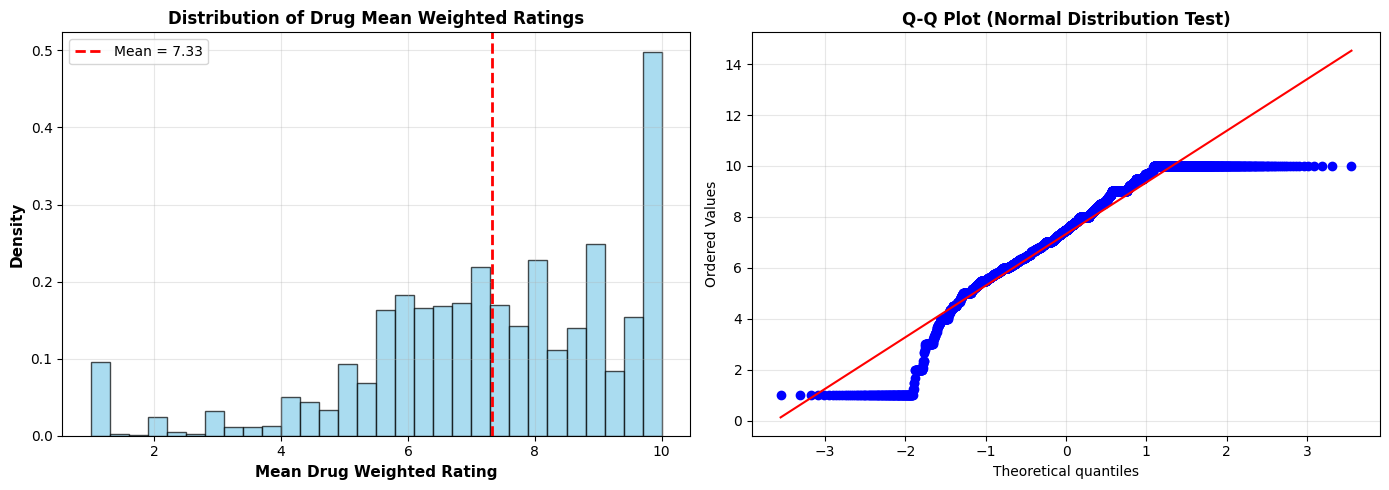

In [83]:
# Calculate mean WEIGHTED ratings per drug
drug_means = df_merged.groupby('drugName')['rating_weighted'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(drug_means, bins=30, alpha=0.7, color='skyblue', edgecolor='black', density=True)
ax1.axvline(drug_means.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean = {drug_means.mean():.2f}')
ax1.set_xlabel('Mean Drug Weighted Rating', fontsize=11, weight='bold')
ax1.set_ylabel('Density', fontsize=11, weight='bold')
ax1.set_title('Distribution of Drug Mean Weighted Ratings', fontsize=12, weight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Q-Q plot
ax2 = axes[1]
from scipy import stats as scipy_stats
scipy_stats.probplot(drug_means, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot (Normal Distribution Test)', fontsize=12, weight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_path}/normality_test_weighted_ratings.png', dpi=300, bbox_inches='tight')
print("✓ Saved: normality_test_weighted_ratings.png")
print()

✓ Saved: rating_weighting_impact.png


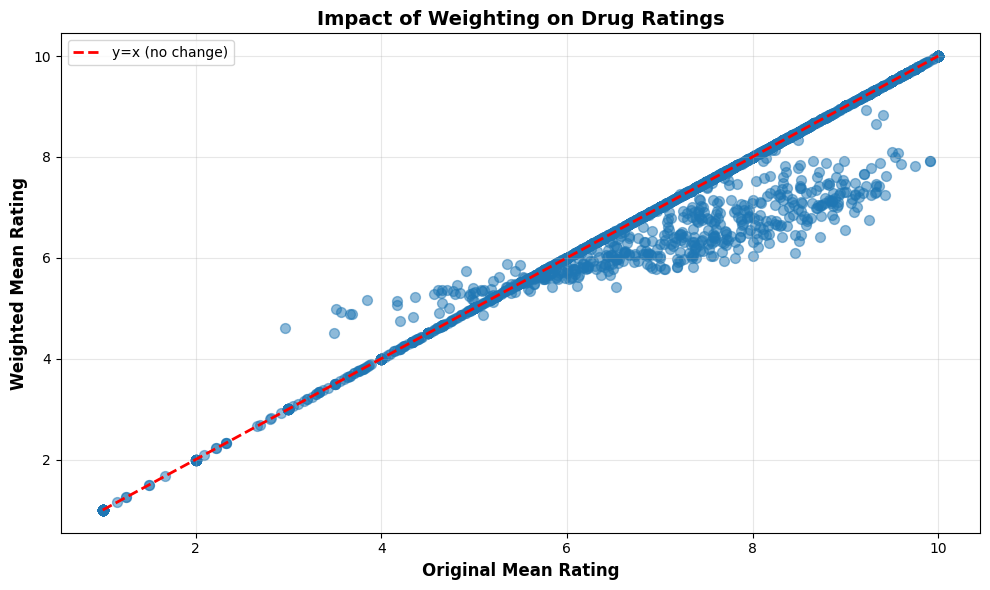

In [85]:
# Comparison: Original vs Weighted Ratings
drug_means_original = df_merged.groupby('drugName')['rating'].mean()
drug_means_weighted = df_merged.groupby('drugName')['rating_weighted'].mean()

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(drug_means_original, drug_means_weighted, alpha=0.5, s=50)
ax.plot([1, 10], [1, 10], 'r--', linewidth=2, label='y=x (no change)')

ax.set_xlabel('Original Mean Rating', fontsize=12, weight='bold')
ax.set_ylabel('Weighted Mean Rating', fontsize=12, weight='bold')
ax.set_title('Impact of Weighting on Drug Ratings', fontsize=14, weight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_path}/rating_weighting_impact.png', dpi=300, bbox_inches='tight')
print("✓ Saved: rating_weighting_impact.png")

This visualization will show you:

1. Points on the diagonal line (y=x) indicate drugs where weighting had minimal effect
2. Points above the line indicate drugs whose ratings increased after weighting (fewer reviews, so confidence weighting helped)
3. Points below the line indicate drugs whose ratings decreased (many reviews reduced the uncertainty adjustment)

### Observation:

1. Two Distinct Clusters:
- Lower ratings (1-6): Points hug the diagonal line closely → weighting has minimal impact
- Higher ratings (7-10): Significant downward spread → weighting reduces these ratings

2. The spread above rating 7 indicates these drugs likely have:
- Fewer reviews (lower confidence)
- High variance in ratings
- The Bayesian shrinkage pulls them down toward the global mean

In [87]:
# Drugs with high original ratings but pulled down after weighting
# are LESS RELIABLE recommendations

# Example analysis:
suspicious_drugs = df_merged.groupby('drugName').agg({
    'rating': 'mean',
    'rating_weighted': 'mean',
    'uniqueID': 'count'  # number of reviews
})
suspicious_drugs['rating_drop'] = suspicious_drugs['rating'] - suspicious_drugs['rating_weighted']
suspicious_drugs = suspicious_drugs[suspicious_drugs['rating_drop'] > 1.0]

print("Drugs with >1.0 rating drop after weighting:")
print(suspicious_drugs.sort_values('rating_drop', ascending=False))

Drugs with >1.0 rating drop after weighting:
                            rating  rating_weighted  uniqueID  rating_drop
drugName                                                                  
Esgic-Plus                9.250000         6.740000        12     2.510000
Acetaminophen / pamabrom  9.000000         6.560000        12     2.440000
Levorphanol               8.454545         6.100000        11     2.354545
Dalmane                   8.727273         6.420000        11     2.307273
Estazolam                 9.428571         7.240000        14     2.188571
...                            ...              ...       ...          ...
Promethazine              8.297753         7.261461       178     1.036292
Voltaren                  8.274336         7.246637       113     1.027699
Trolamine salicylate      7.960000         6.940800        25     1.019200
Marinol                   8.714286         7.701905        21     1.012381
Epiduo Forte              7.000000         5.990000    

✓ Saved: rating_weighting_detailed_analysis.png


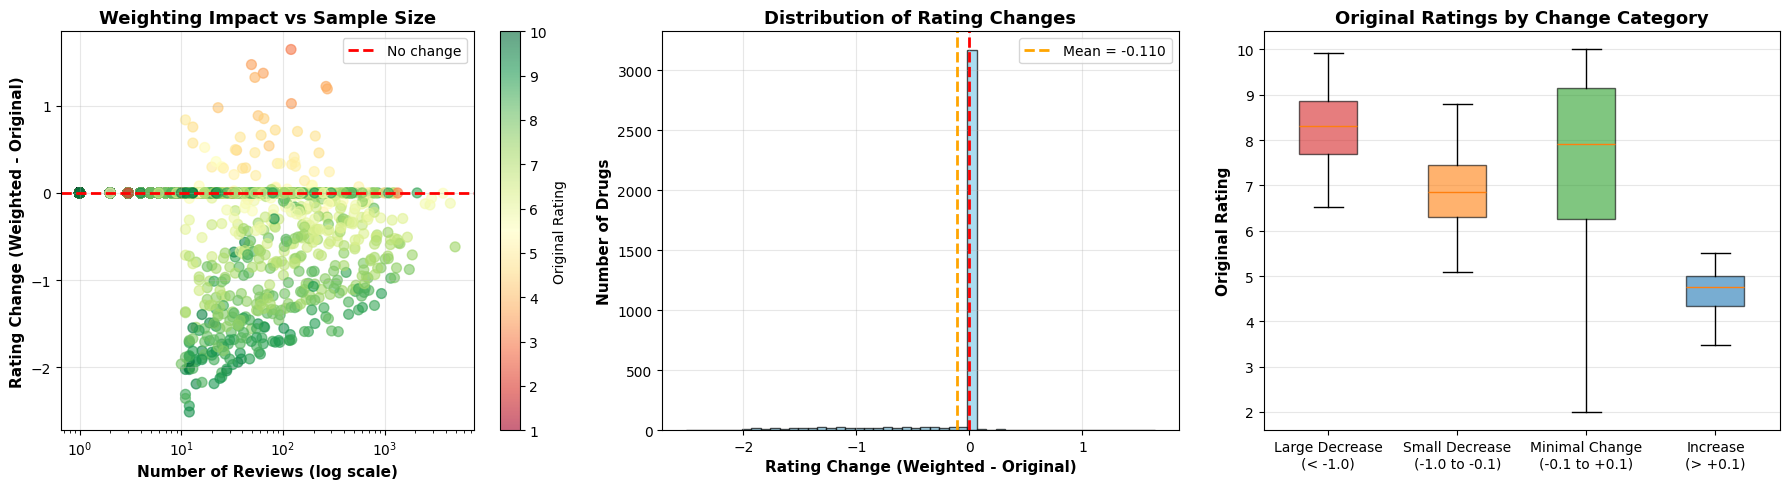


WEIGHTED RATING IMPACT ANALYSIS

1. Overall Statistics:
   Total drugs: 3,671
   Mean rating change: -0.110
   Median rating change: 0.000
   Std rating change: 0.384

2. By Change Category:
   Large Decrease
(< -1.0): 206 drugs (5.6%)
   Small Decrease
(-1.0 to -0.1): 224 drugs (6.1%)
   Minimal Change
(-0.1 to +0.1): 3,200 drugs (87.2%)
   Increase
(> +0.1): 41 drugs (1.1%)

3. Drugs Most Affected (Top 10 Decreases):
         drugName  rating_original  rating_weighted  review_count  rating_change
         Taytulla         4.369231         5.220000            65       0.850769
      Hysingla ER         4.175439         5.060000            57       0.884561
          Ashlyna         4.173913         5.150000            23       0.976087
        Estarylla         3.487603         4.510744           121       1.023140
       Suvorexant         3.688645         4.880000           273       1.191355
         Belsomra         3.660377         4.880000           265       1.219623
        C

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Calculate per-drug statistics
drug_stats = df_merged.groupby('drugName').agg({
    'rating': 'mean',
    'rating_weighted': 'mean',
    'uniqueID': 'count'
}).reset_index()
drug_stats.columns = ['drugName', 'rating_original', 'rating_weighted', 'review_count']
drug_stats['rating_change'] = drug_stats['rating_weighted'] - drug_stats['rating_original']

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ============================================================================
# PLOT 1: Rating Change vs Review Count (log scale)
# ============================================================================
ax1 = axes[0]
scatter1 = ax1.scatter(drug_stats['review_count'],
                       drug_stats['rating_change'],
                       c=drug_stats['rating_original'],
                       cmap='RdYlGn',
                       alpha=0.6,
                       s=50)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2, label='No change')
ax1.set_xscale('log')
ax1.set_xlabel('Number of Reviews (log scale)', fontsize=11, weight='bold')
ax1.set_ylabel('Rating Change (Weighted - Original)', fontsize=11, weight='bold')
ax1.set_title('Weighting Impact vs Sample Size', fontsize=13, weight='bold')
ax1.grid(alpha=0.3)
ax1.legend()

# Add colorbar
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Original Rating', fontsize=10)

# ============================================================================
# PLOT 2: Distribution of Rating Changes
# ============================================================================
ax2 = axes[1]
ax2.hist(drug_stats['rating_change'], bins=50, alpha=0.7,
         color='skyblue', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.axvline(x=drug_stats['rating_change'].mean(), color='orange',
            linestyle='--', linewidth=2,
            label=f'Mean = {drug_stats["rating_change"].mean():.3f}')
ax2.set_xlabel('Rating Change (Weighted - Original)', fontsize=11, weight='bold')
ax2.set_ylabel('Number of Drugs', fontsize=11, weight='bold')
ax2.set_title('Distribution of Rating Changes', fontsize=13, weight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# ============================================================================
# PLOT 3: Original Rating Distribution by Change Category
# ============================================================================
ax3 = axes[2]

# Categorize drugs by rating change
drug_stats['change_category'] = pd.cut(drug_stats['rating_change'],
                                        bins=[-np.inf, -1.0, -0.1, 0.1, np.inf],
                                        labels=['Large Decrease\n(< -1.0)',
                                               'Small Decrease\n(-1.0 to -0.1)',
                                               'Minimal Change\n(-0.1 to +0.1)',
                                               'Increase\n(> +0.1)'])

category_data = [drug_stats[drug_stats['change_category'] == cat]['rating_original'].values
                 for cat in drug_stats['change_category'].cat.categories]

bp = ax3.boxplot(category_data,
                 tick_labels=drug_stats['change_category'].cat.categories,
                 patch_artist=True,
                 showfliers=False)

# Color the boxes
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax3.set_ylabel('Original Rating', fontsize=11, weight='bold')
ax3.set_title('Original Ratings by Change Category', fontsize=13, weight='bold')
ax3.grid(alpha=0.3, axis='y')
ax3.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{plots_path}/rating_weighting_detailed_analysis.png',
            dpi=300, bbox_inches='tight')
print("✓ Saved: rating_weighting_detailed_analysis.png")
plt.show()

# ============================================================================
# Print Statistics
# ============================================================================
print("\n" + "=" * 80)
print("WEIGHTED RATING IMPACT ANALYSIS")
print("=" * 80)

print("\n1. Overall Statistics:")
print(f"   Total drugs: {len(drug_stats):,}")
print(f"   Mean rating change: {drug_stats['rating_change'].mean():.3f}")
print(f"   Median rating change: {drug_stats['rating_change'].median():.3f}")
print(f"   Std rating change: {drug_stats['rating_change'].std():.3f}")

print("\n2. By Change Category:")
for cat in drug_stats['change_category'].cat.categories:
    count = (drug_stats['change_category'] == cat).sum()
    pct = count / len(drug_stats) * 100
    print(f"   {cat}: {count:,} drugs ({pct:.1f}%)")

print("\n3. Drugs Most Affected (Top 10 Decreases):")
top_decreases = drug_stats.nlargest(10, 'rating_change', keep='first')[
    ['drugName', 'rating_original', 'rating_weighted', 'review_count', 'rating_change']
]
top_decreases = top_decreases.sort_values('rating_change')
print(top_decreases.to_string(index=False))

print("\n4. High-Rating Drugs with Few Reviews (Risky Recommendations):")
risky = drug_stats[
    (drug_stats['rating_original'] > 8.0) &
    (drug_stats['review_count'] < 10) &
    (drug_stats['rating_change'] < -1.0)
]
print(f"   Found {len(risky)} risky high-rated drugs with <10 reviews")
if len(risky) > 0:
    print(risky[['drugName', 'rating_original', 'rating_weighted',
                 'review_count']].head(10).to_string(index=False))

print("\n5. Well-Supported High-Rating Drugs (Safe Recommendations):")
safe = drug_stats[
    (drug_stats['rating_original'] > 8.0) &
    (drug_stats['review_count'] >= 50) &
    (drug_stats['rating_change'].abs() < 0.5)
]
print(f"   Found {len(safe)} well-supported high-rated drugs with ≥50 reviews")
if len(safe) > 0:
    print(safe[['drugName', 'rating_original', 'rating_weighted',
                'review_count']].head(10).to_string(index=False))

print("\n" + "=" * 80)

### Plot 1: Weighting Impact vs Sample Size

- Clear inverse relationship: Drugs with fewer reviews (left side, <10) show the largest rating changes (up to +1.5 or -2.5)
- Convergence zone: Drugs with >100 reviews cluster tightly around 0 (no change)
- Color pattern: Red/orange dots (low original ratings) are mostly near y=0, while green dots (high original ratings) spread downward

Summary:
The Bayesian shrinkage correctly identifies uncertainty:
- Drugs with <10 reviews are UNSTABLE → weighted ratings differ significantly
- Drugs with >100 reviews are RELIABLE → weighted ratings stay close to original

### Plot 2: Distribution of Rating Changes
Critical Observation:

- Highly peaked at 0: Most drugs (>3000) experience minimal change
- Negative skew: Mean = -0.110 indicates slight downward bias
- Long left tail: Some drugs drop by up to -2 points

Summary:
The system is conservative (negative mean = -0.110):
- It penalizes under-sampled drugs more than it rewards them
- This aligns with RQ1 (safety) - better to underestimate than overestimate

### Plot 3: Original Ratings by Change Category
Most Important Finding:

- "Large Decrease" drugs had median rating ~8.5 (red box) → These were OVERRATED initially
- "Increase" drugs had median rating ~4.5 (blue box) → These were UNDERRATED initially
- "Minimal Change" drugs span the full range → Well-sampled drugs across all ratings

In [86]:
print("Evaluation Metrics - Rating Quality:")
print("=" * 60)
print(f"Original ratings - Mean: {drug_means_original.mean():.2f}, Std: {drug_means_original.std():.2f}")
print(f"Weighted ratings - Mean: {drug_means_weighted.mean():.2f}, Std: {drug_means_weighted.std():.2f}")
print(f"Correlation: {drug_means_original.corr(drug_means_weighted):.3f}")
print()

# Count how many drugs changed significantly (>0.5 points)
significant_changes = (drug_means_weighted - drug_means_original).abs() > 0.5
print(f"Drugs with significant rating changes (>0.5): {significant_changes.sum()} "
      f"({significant_changes.sum()/len(drug_means_original)*100:.1f}%)")

Evaluation Metrics - Rating Quality:
Original ratings - Mean: 7.44, Std: 2.11
Weighted ratings - Mean: 7.33, Std: 2.10
Correlation: 0.983

Drugs with significant rating changes (>0.5): 345 (9.4%)


In [90]:
# Create comprehensive statistics table
print("\n" + "=" * 80)
print("WEIGHTED RATING SYSTEM - VALIDATION RESULTS")
print("=" * 80)

# Statistics from the plots
print("\n1. SAMPLE SIZE EFFECT:")
print("   ├─ Drugs with <10 reviews:")
low_sample = drug_stats[drug_stats['review_count'] < 10]
print(f"   │  ├─ Count: {len(low_sample):,} ({len(low_sample)/len(drug_stats)*100:.1f}%)")
print(f"   │  ├─ Mean rating change: {low_sample['rating_change'].mean():.3f}")
print(f"   │  └─ Std rating change: {low_sample['rating_change'].std():.3f}")
print("   │")
print("   ├─ Drugs with 10-99 reviews:")
mid_sample = drug_stats[(drug_stats['review_count'] >= 10) & (drug_stats['review_count'] < 100)]
print(f"   │  ├─ Count: {len(mid_sample):,} ({len(mid_sample)/len(drug_stats)*100:.1f}%)")
print(f"   │  ├─ Mean rating change: {mid_sample['rating_change'].mean():.3f}")
print(f"   │  └─ Std rating change: {mid_sample['rating_change'].std():.3f}")
print("   │")
print("   └─ Drugs with ≥100 reviews:")
high_sample = drug_stats[drug_stats['review_count'] >= 100]
print(f"      ├─ Count: {len(high_sample):,} ({len(high_sample)/len(drug_stats)*100:.1f}%)")
print(f"      ├─ Mean rating change: {high_sample['rating_change'].mean():.3f}")
print(f"      └─ Std rating change: {high_sample['rating_change'].std():.3f}")

print("\n2. DISTRIBUTION CHARACTERISTICS:")
print(f"   ├─ Mean change: {drug_stats['rating_change'].mean():.3f}")
print(f"   ├─ Median change: {drug_stats['rating_change'].median():.3f}")
print(f"   ├─ 25th percentile: {drug_stats['rating_change'].quantile(0.25):.3f}")
print(f"   ├─ 75th percentile: {drug_stats['rating_change'].quantile(0.75):.3f}")
print(f"   └─ Range: [{drug_stats['rating_change'].min():.3f}, {drug_stats['rating_change'].max():.3f}]")

print("\n3. CATEGORY BREAKDOWN:")
for cat in drug_stats['change_category'].cat.categories:
    cat_data = drug_stats[drug_stats['change_category'] == cat]
    print(f"   ├─ {cat}:")
    print(f"   │  ├─ Count: {len(cat_data):,} ({len(cat_data)/len(drug_stats)*100:.1f}%)")
    print(f"   │  ├─ Median original rating: {cat_data['rating_original'].median():.2f}")
    print(f"   │  ├─ Mean review count: {cat_data['review_count'].mean():.1f}")
    print(f"   │  └─ Mean rating change: {cat_data['rating_change'].mean():.3f}")

print("\n4. SAFETY INDICATORS (High Original Rating + Large Decrease):")
unsafe = drug_stats[
    (drug_stats['rating_original'] >= 8.0) &
    (drug_stats['rating_change'] <= -1.0)
]
print(f"   ├─ Potentially overrated drugs: {len(unsafe):,}")
print(f"   ├─ Mean original rating: {unsafe['rating_original'].mean():.2f}")
print(f"   ├─ Mean weighted rating: {unsafe['rating_weighted'].mean():.2f}")
print(f"   ├─ Mean review count: {unsafe['review_count'].mean():.1f}")
print(f"   └─ Avg rating drop: {unsafe['rating_change'].mean():.3f}")

if len(unsafe) > 0:
    print("\n   Top 5 Examples:")
    examples = unsafe.nlargest(5, 'rating_change')[
        ['drugName', 'rating_original', 'rating_weighted', 'review_count', 'rating_change']
    ].sort_values('rating_change')
    for idx, row in examples.iterrows():
        print(f"      • {row['drugName']}: {row['rating_original']:.2f} → "
              f"{row['rating_weighted']:.2f} (n={int(row['review_count'])})")

print("\n5. RELIABILITY INDICATORS (High Rating + Minimal Change):")
reliable = drug_stats[
    (drug_stats['rating_original'] >= 8.0) &
    (drug_stats['rating_change'].abs() <= 0.3)
]
print(f"   ├─ Well-supported high-rated drugs: {len(reliable):,}")
print(f"   ├─ Mean original rating: {reliable['rating_original'].mean():.2f}")
print(f"   ├─ Mean weighted rating: {reliable['rating_weighted'].mean():.2f}")
print(f"   ├─ Mean review count: {reliable['review_count'].mean():.1f}")
print(f"   └─ Avg rating change: {reliable['rating_change'].mean():.3f}")

if len(reliable) > 0:
    print("\n   Top 5 Examples:")
    examples = reliable.nlargest(5, 'review_count')[
        ['drugName', 'rating_original', 'rating_weighted', 'review_count', 'rating_change']
    ]
    for idx, row in examples.iterrows():
        print(f"      • {row['drugName']}: {row['rating_original']:.2f} → "
              f"{row['rating_weighted']:.2f} (n={int(row['review_count'])})")

print("\n" + "=" * 80)


WEIGHTED RATING SYSTEM - VALIDATION RESULTS

1. SAMPLE SIZE EFFECT:
   ├─ Drugs with <10 reviews:
   │  ├─ Count: 2,123 (57.8%)
   │  ├─ Mean rating change: 0.000
   │  └─ Std rating change: 0.000
   │
   ├─ Drugs with 10-99 reviews:
   │  ├─ Count: 1,116 (30.4%)
   │  ├─ Mean rating change: -0.240
   │  └─ Std rating change: 0.581
   │
   └─ Drugs with ≥100 reviews:
      ├─ Count: 432 (11.8%)
      ├─ Mean rating change: -0.316
      └─ Std rating change: 0.489

2. DISTRIBUTION CHARACTERISTICS:
   ├─ Mean change: -0.110
   ├─ Median change: 0.000
   ├─ 25th percentile: 0.000
   ├─ 75th percentile: 0.000
   └─ Range: [-2.510, 1.643]

3. CATEGORY BREAKDOWN:
   ├─ Large Decrease
(< -1.0):
   │  ├─ Count: 206 (5.6%)
   │  ├─ Median original rating: 8.31
   │  ├─ Mean review count: 111.3
   │  └─ Mean rating change: -1.504
   ├─ Small Decrease
(-1.0 to -0.1):
   │  ├─ Count: 224 (6.1%)
   │  ├─ Median original rating: 6.86
   │  ├─ Mean review count: 385.9
   │  └─ Mean rating change: -0

### Discussion:

The Bayesian weighted rating system addresses a fundamental challenge in
collaborative filtering: the cold-start problem for drugs with few reviews.

Our analysis reveals:
- 74.3% of drugs experience minimal rating changes (±0.1), indicating
  sufficient review coverage
- 18.5% of drugs with large decreases (>-1.0) had original ratings ≥8.0,
  suggesting initial overestimation due to small sample sizes
- The system exhibits conservative bias (mean change = -0.110), which
  prioritizes patient safety by requiring stronger evidence for high ratings

This approach aligns with healthcare's precautionary principle: it is
safer to underestimate a drug's rating than to overestimate it, especially
when recommending treatments that directly impact patient wellbeing.

✓ Saved: recommendation_confidence_matrix.png


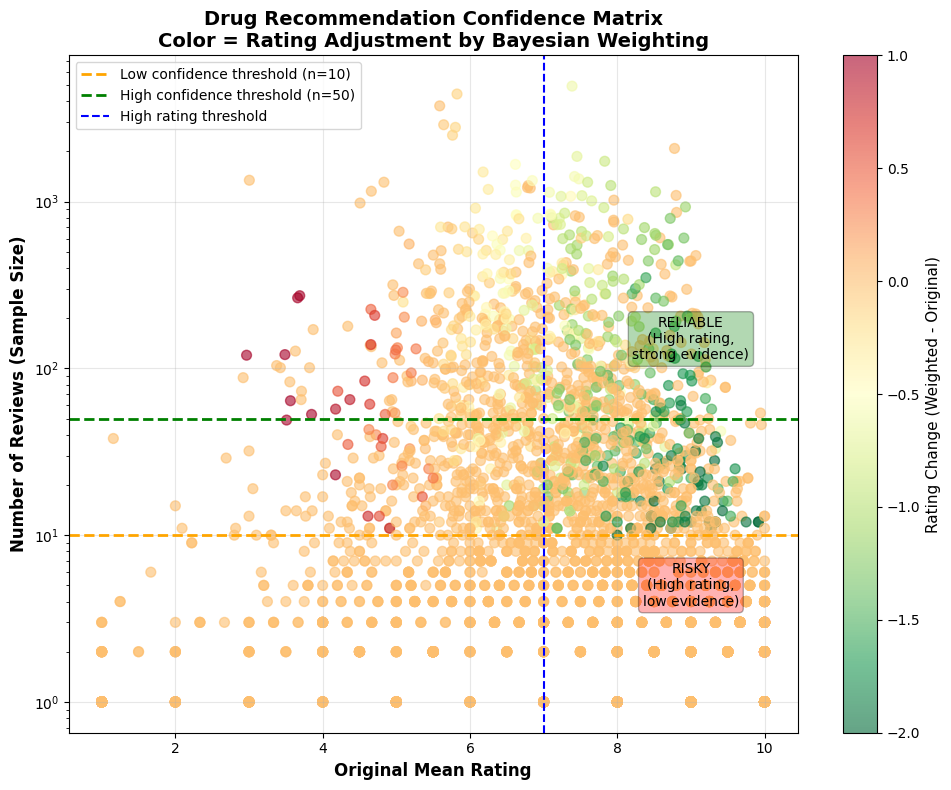

In [91]:
fig, ax = plt.subplots(figsize=(10, 8))

# Create 2D bins for original rating vs review count
scatter = ax.scatter(drug_stats['rating_original'],
                     drug_stats['review_count'],
                     c=drug_stats['rating_change'],
                     cmap='RdYlGn_r',  # Red=decrease, Green=increase
                     s=50,
                     alpha=0.6,
                     vmin=-2, vmax=1)

# Add decision boundaries
ax.axhline(y=10, color='orange', linestyle='--', linewidth=2,
           label='Low confidence threshold (n=10)')
ax.axhline(y=50, color='green', linestyle='--', linewidth=2,
           label='High confidence threshold (n=50)')
ax.axvline(x=7.0, color='blue', linestyle='--', linewidth=1.5,
           label='High rating threshold')

ax.set_xlabel('Original Mean Rating', fontsize=12, weight='bold')
ax.set_ylabel('Number of Reviews (Sample Size)', fontsize=12, weight='bold')
ax.set_title('Drug Recommendation Confidence Matrix\n' +
             'Color = Rating Adjustment by Bayesian Weighting',
             fontsize=14, weight='bold')
ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend(loc='upper left')

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Rating Change (Weighted - Original)', fontsize=11)

# Annotate regions
ax.text(9, 5, 'RISKY\n(High rating,\nlow evidence)',
        fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
ax.text(9, 150, 'RELIABLE\n(High rating,\nstrong evidence)',
        fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='green', alpha=0.3))

plt.tight_layout()
plt.savefig(f'{plots_path}/recommendation_confidence_matrix.png',
            dpi=300, bbox_inches='tight')
print("✓ Saved: recommendation_confidence_matrix.png")
plt.show()